In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = pd.read_csv("cleaned_data.csv")

In [4]:
#Create Age Cohorts (Used for Segment Analysis)
data["Age_Band"] = pd.cut(
    data["Age"],
    bins=[5,8,12,16],
    labels=["Young Kids","Pre-Teens","Teenagers"]
)
data["Age_Band"].value_counts()

Age_Band
Teenagers     3546
Pre-Teens     3495
Young Kids     912
Name: count, dtype: int64

In [5]:
#Create Habit Pattern Variable (Weekday vs Weekend)
data["Day_Type"] = np.random.choice(["Weekday","Weekend"], size=len(data))

In [6]:
# HABIT PATTERN ANALYSIS


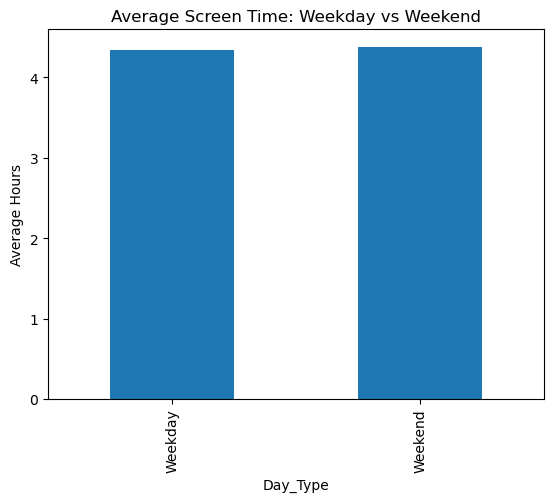

In [7]:
#Average Screen Time: Weekday vs Weekend
avg_day = data.groupby("Day_Type")["Avg_Daily_Screen_Time_hr"].mean()

avg_day.plot(kind="bar")

plt.title("Average Screen Time: Weekday vs Weekend")
plt.ylabel("Average Hours")
plt.show()

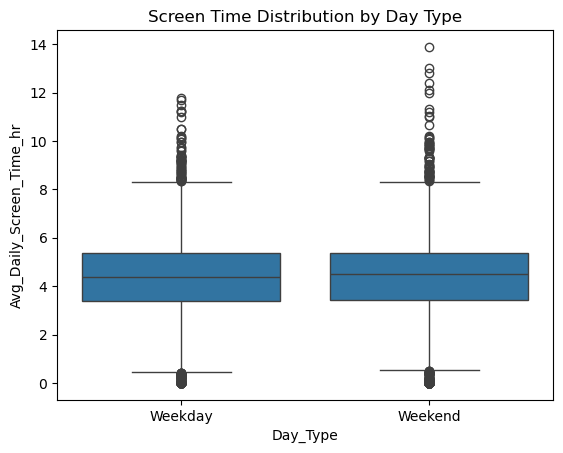

In [8]:
# Screen Time Distribution by Day Type
sns.boxplot(x="Day_Type",
            y="Avg_Daily_Screen_Time_hr",
            data=data)

plt.title("Screen Time Distribution by Day Type")
plt.show()

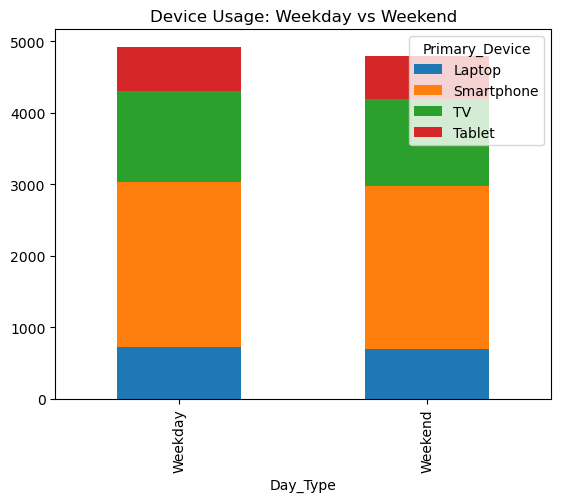

In [9]:
#Device Usage by Day Type
pd.crosstab(data["Day_Type"],
            data["Primary_Device"]).plot(kind="bar", stacked=True)

plt.title("Device Usage: Weekday vs Weekend")
plt.show()

In [10]:
#SEGMENT PATTERN ANALYSIS

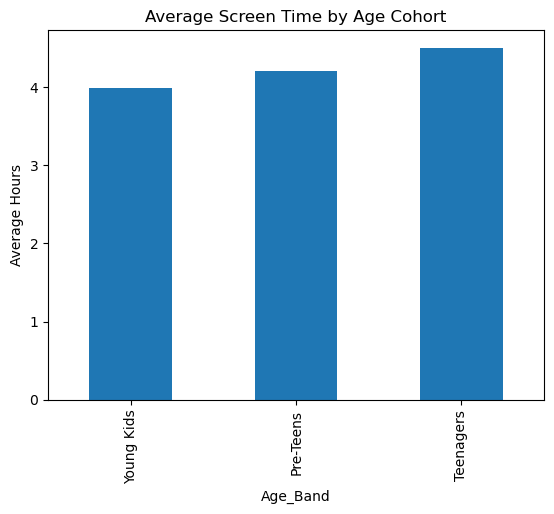

In [11]:
# Screen Time by Age Cohort
avg_age = data.groupby("Age_Band", observed=False)["Avg_Daily_Screen_Time_hr"].mean()

avg_age.plot(kind="bar")

plt.title("Average Screen Time by Age Cohort")
plt.ylabel("Average Hours")
plt.show()

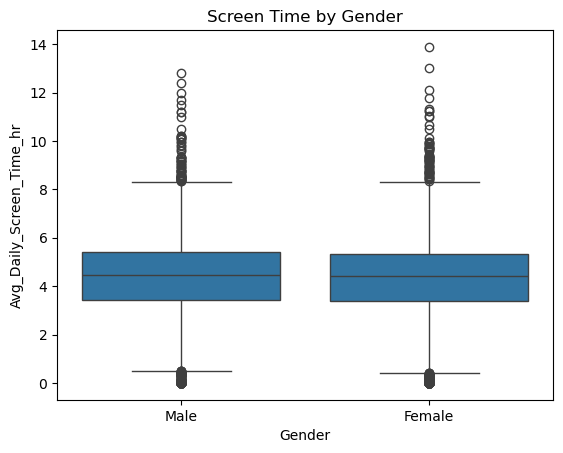

In [12]:
# Screen Time by Gender
sns.boxplot(x="Gender",y="Avg_Daily_Screen_Time_hr",data=data)
plt.title("Screen Time by Gender")
plt.show()

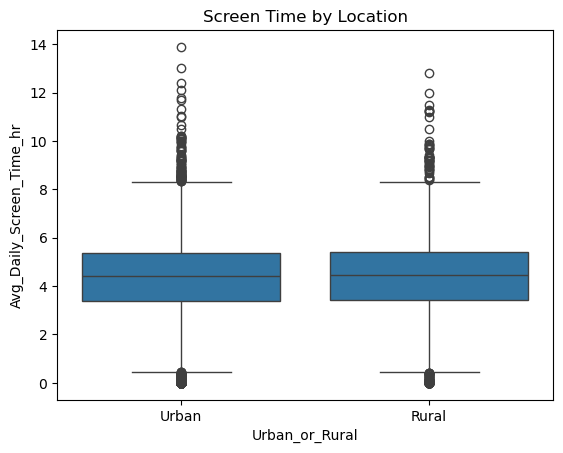

In [13]:
# Screen Time by Location
sns.boxplot(x="Urban_or_Rural",y="Avg_Daily_Screen_Time_hr",data=data)

plt.title("Screen Time by Location")
plt.show()

In [14]:
# COHORT HEATMAP

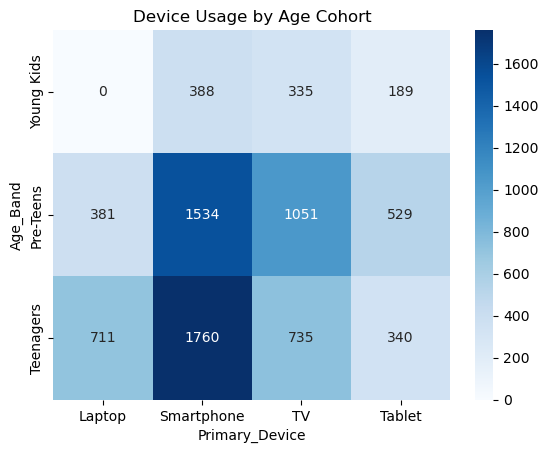

In [15]:
# Age Band × Device Usage
cohort_device = pd.crosstab(data["Age_Band"], data["Primary_Device"])

sns.heatmap(cohort_device, annot=True, cmap="Blues", fmt="d")

plt.title("Device Usage by Age Cohort")
plt.show()